# UNIVERSIDADE REGIONAL DE BLUMENAU - FURB
**DISCIPLINA**: Processamento de Imagens  
**ALUNO/EQUIPE**: Gabriel 

---

# TRABALHO PRÁTICO 02 [OPERADORES MORFOLÓGICOS]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
from skimage.morphology import disk

def show_img(title, img, cmap='gray'):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

## 1. Obtenção da Imagem


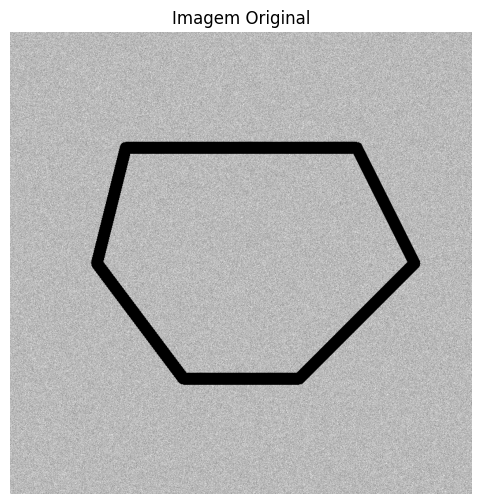

In [2]:
img_gray = np.ones((800, 800), dtype=np.uint8) * 200
noise = np.random.normal(0, 15, (800, 800))
img_gray = np.clip(img_gray + noise, 0, 255).astype(np.uint8)

pts = np.array([[200, 200], [600, 200], [700, 400], [500, 600], [300, 600], [150, 400]], np.int32)
pts = pts.reshape((-1, 1, 2))
cv2.polylines(img_gray, [pts], isClosed=True, color=50, thickness=20)

img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

show_img("Imagem Original", img_gray)

## 2. Pré-processamento


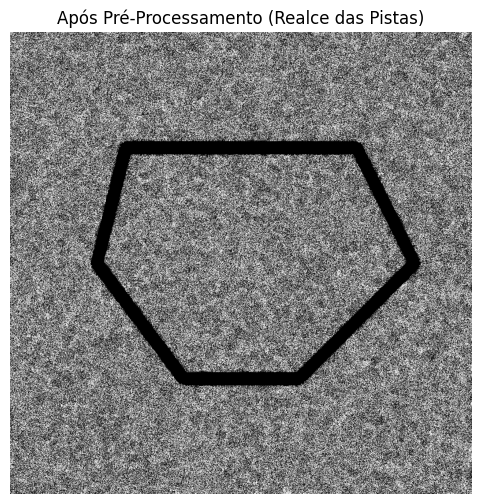

In [3]:
kernel_disk = disk(5)
closeth = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel_disk)

histeq = cv2.equalizeHist(closeth)
subm = histeq.copy()

show_img("Após Pré-Processamento (Realce das Pistas)", subm)

## 3. Detecção e Pós-processamento


C:\Users\gabri\AppData\Local\Temp\ipykernel_15800\76118125.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  areaclose1 = morphology.remove_small_objects(thresh_bool, min_size=500)
C:\Users\gabri\AppData\Local\Temp\ipykernel_15800\76118125.py:12: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  final_bool = morpho

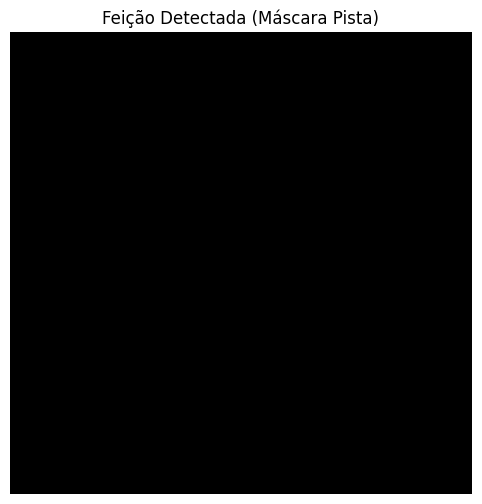

In [4]:
_, thresh_img = cv2.threshold(subm, 200, 255, cv2.THRESH_BINARY)
thresh_bool = thresh_img > 0
areaclose1 = morphology.remove_small_objects(thresh_bool, min_size=500)

kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
areaclose1_uint = areaclose1.astype(np.uint8) * 255
dilated = cv2.dilate(areaclose1_uint, kernel_cross, iterations=2)

eroded = cv2.erode(dilated, kernel_cross, iterations=1)

eroded_bool = eroded > 0
final_bool = morphology.remove_small_objects(eroded_bool, min_size=300)
final_feat = final_bool.astype(np.uint8) * 255

show_img("Feição Detectada (Máscara Pista)", final_feat)

## 4. Resultado (Sobreposição)


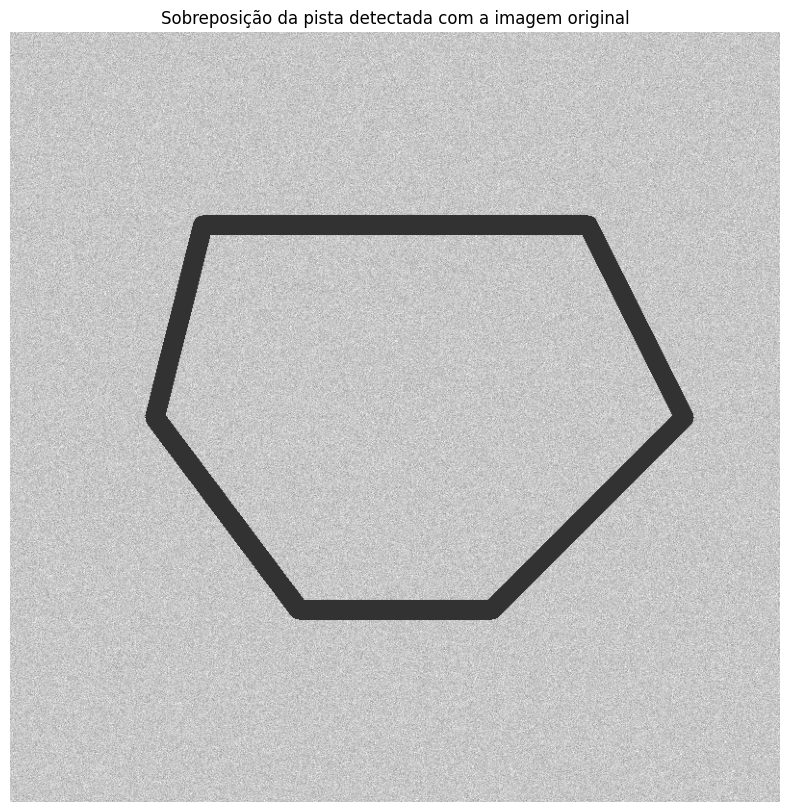

In [5]:
overlay = img_rgb.copy()
overlay[final_feat == 255] = [255, 0, 0]

alpha = 0.6
result = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

plt.figure(figsize=(12, 10))
plt.title("Sobreposição da pista detectada com a imagem original")
plt.imshow(result)
plt.axis('off')
plt.show()